# Track B — 이미지/라벨 EDA
> 목적: class_id 분포 확인 → dataset.yaml 클래스 매핑 확정

In [20]:
import os

os.getcwd()

'c:\\work\\python_area\\AIotDataAnalysis\\workspace_python\\프로젝트2'

In [21]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

# 한글 폰트 설정 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

LABEL_TRAIN = Path('./dataset/track_a_images/labels/train')
LABEL_VAL   = Path('./dataset/track_a_images/labels/val')
IMG_TRAIN   = Path('./dataset/track_a_images/images/train')

print('경로 확인')
print('train 라벨:', LABEL_TRAIN.exists(), '| 파일 수:', len(list(LABEL_TRAIN.glob('*.txt'))))
print('val   라벨:', LABEL_VAL.exists(),   '| 파일 수:', len(list(LABEL_VAL.glob('*.txt'))))
print('train 이미지:', IMG_TRAIN.exists(), '| 파일 수:', len(list(IMG_TRAIN.glob('*.jpg'))))

경로 확인
train 라벨: True | 파일 수: 800
val   라벨: True | 파일 수: 200
train 이미지: True | 파일 수: 800


## 1. 라벨 전체 파싱

In [22]:
records = []

for txt_file in LABEL_TRAIN.glob('*.txt'):
    lines = txt_file.read_text().strip().splitlines()
    if not lines:
        records.append({'file': txt_file.stem, 'class_id': -1,
                        'cx': None, 'cy': None, 'w': None, 'h': None})
        continue
    for line in lines:
        cls, cx, cy, w, h = map(float, line.split())
        records.append({'file': txt_file.stem, 'class_id': int(cls),
                        'cx': cx, 'cy': cy, 'w': w, 'h': h})

df = pd.DataFrame(records)
print(f'총 라벨 수: {len(df)}')
print(f'총 이미지 수: {df["file"].nunique()}')

총 라벨 수: 1177
총 이미지 수: 800


## 2. class_id 분포 — ★ 이 출력으로 dataset.yaml 매핑 확정

In [23]:
positive = df[df['class_id'] >= 0]

print('=== class_id 분포 (★ Claude에게 공유) ===')
vc = positive['class_id'].value_counts().sort_index()
print(vc)
print(f'\n고유 class_id 수: {positive["class_id"].nunique()}')
print(f'class_id 범위: {positive["class_id"].min()} ~ {positive["class_id"].max()}')

=== class_id 분포 (★ Claude에게 공유) ===
class_id
0    260
1    204
2    135
3    102
4    118
5     98
6     49
7     78
Name: count, dtype: int64

고유 class_id 수: 8
class_id 범위: 0 ~ 7


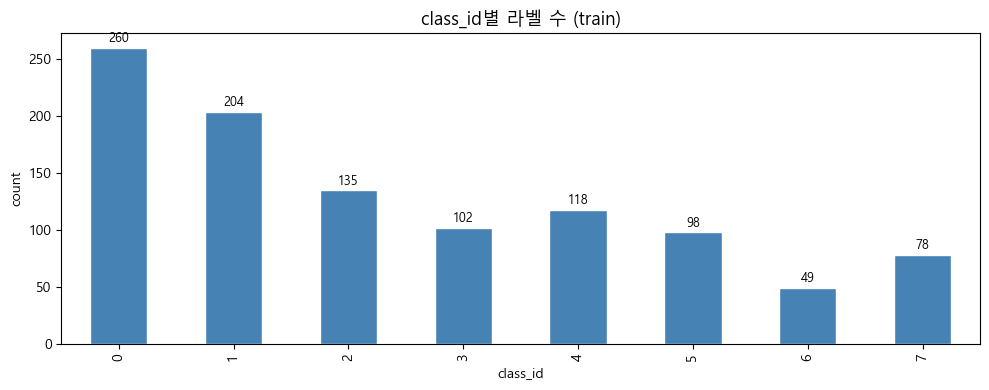

불균형 비율 (최다/최소): 5.3 :1


In [24]:
# 클래스 불균형 시각화
fig, ax = plt.subplots(figsize=(10, 4))
vc.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('class_id별 라벨 수 (train)', fontsize=13)
ax.set_xlabel('class_id')
ax.set_ylabel('count')
for i, v in enumerate(vc):
    ax.text(i, v + 5, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=100)
plt.show()
print('불균형 비율 (최다/최소):', round(vc.max() / vc.min(), 1), ':1')

## 3. Negative sample (빈 라벨) 비율

In [25]:
total_imgs  = df['file'].nunique()
empty_imgs  = (df['class_id'] == -1).sum()
print(f'negative sample: {empty_imgs} / {total_imgs} ({empty_imgs/total_imgs*100:.1f}%)')
print(f'positive sample: {total_imgs - empty_imgs} / {total_imgs} ({(total_imgs-empty_imgs)/total_imgs*100:.1f}%)')

negative sample: 133 / 800 (16.6%)
positive sample: 667 / 800 (83.4%)


## 4. BBox 크기 분포

In [27]:
df['area'] = df['w'] * df['h']
positive = df[df['class_id'] >= 0]   # area 컬럼 포함하여 재필터

print('=== BBox 크기 통계 ===')
print(df[['w', 'h', 'area']].describe().round(4))

print('\n=== class_id별 평균 BBox 면적 ===')
print(positive.groupby('class_id')['area'].mean().round(4))

=== BBox 크기 통계 ===
               w          h       area
count  1044.0000  1044.0000  1044.0000
mean      0.1092     0.1272     0.0095
std       0.1537     0.1266     0.0073
min       0.0125     0.0222     0.0013
25%       0.0469     0.0747     0.0039
50%       0.0703     0.1028     0.0069
75%       0.1127     0.1417     0.0138
max       0.9195     0.8292     0.0408

=== class_id별 평균 BBox 면적 ===
class_id
0    0.0112
1    0.0099
2    0.0046
3    0.0029
4    0.0034
5    0.0115
6    0.0172
7    0.0223
Name: area, dtype: float64


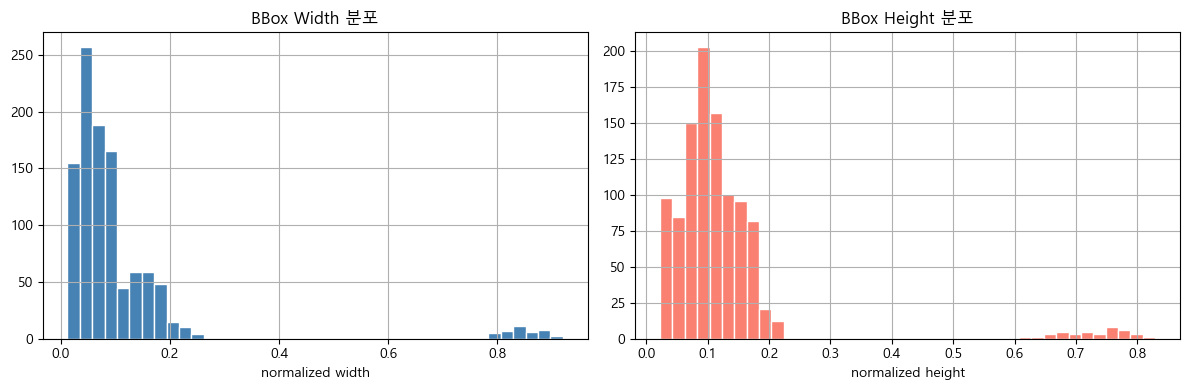

In [28]:
# BBox 크기 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

positive['w'].hist(bins=40, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('BBox Width 분포')
axes[0].set_xlabel('normalized width')

positive['h'].hist(bins=40, ax=axes[1], color='salmon', edgecolor='white')
axes[1].set_title('BBox Height 분포')
axes[1].set_xlabel('normalized height')

plt.tight_layout()
plt.savefig('bbox_distribution.png', dpi=100)
plt.show()

## 5. 샘플 이미지 + BBox 오버레이 (10장)

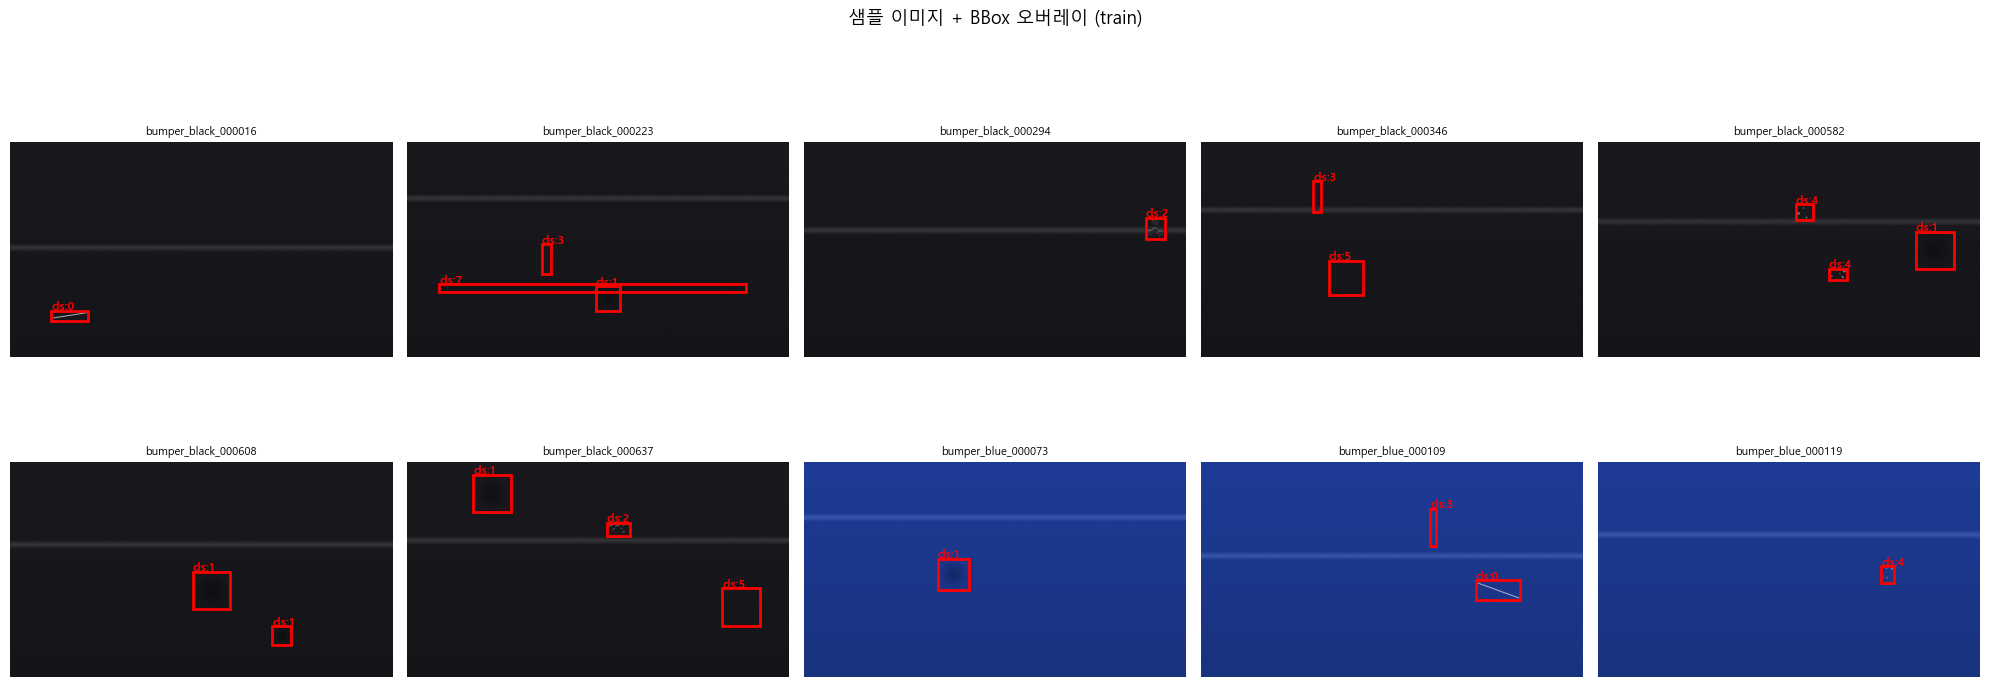

저장 완료: sample_overlay.png


In [29]:
sample_files = [f for f in LABEL_TRAIN.glob('*.txt') if f.read_text().strip()][:10]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for ax, txt_file in zip(axes.flat, sample_files):
    img_path = IMG_TRAIN / (txt_file.stem + '.jpg')
    if not img_path.exists():
        ax.axis('off')
        continue
    img = Image.open(img_path)
    W, H = img.size
    ax.imshow(img)

    for line in txt_file.read_text().strip().splitlines():
        cls, cx, cy, w, h = map(float, line.split())
        x1 = (cx - w/2) * W
        y1 = (cy - h/2) * H
        rect = patches.Rectangle((x1, y1), w*W, h*H,
                                  linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, y1 - 5, f'cls:{int(cls)}', color='red',
                fontsize=8, fontweight='bold')
    ax.set_title(txt_file.stem[:20], fontsize=8)
    ax.axis('off')

plt.suptitle('샘플 이미지 + BBox 오버레이 (train)', fontsize=13)
plt.tight_layout()
plt.savefig('sample_overlay.png', dpi=100)
plt.show()
print('저장 완료: sample_overlay.png')